# Classify Injury Next Season

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#logistic regression and SVM
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AI_Saturday/Machine_Learning/classification_task/data/data.csv')

In [3]:
df.head()

,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


In [4]:
df.shape

(800, 19)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,800.0,21.135000,1.991037,18.000000,19.000000,21.000000,23.000000,24.000000
Height_cm,800.0,177.407500,7.148974,154.000000,173.000000,177.000000,182.000000,200.000000
Weight_kg,800.0,73.235000,9.929276,45.000000,66.000000,73.000000,80.000000,105.000000
Training_Hours_Per_Week,800.0,9.951150,2.610395,5.000000,8.127151,9.895710,11.535140,18.866608
Matches_Played_Past_Season,800.0,22.332500,10.311516,5.000000,13.000000,22.000000,32.000000,39.000000
Previous_Injury_Count,800.0,1.536250,1.292584,0.000000,1.000000,1.000000,2.000000,8.000000
Knee_Strength_Score,800.0,74.933249,6.672704,52.391351,70.432656,74.997933,79.632391,93.900051
Hamstring_Flexibility,800.0,79.154123,6.782332,58.180381,74.495959,79.187909,83.813179,100.000000
Reaction_Time_ms,800.0,249.423244,22.532387,180.000000,234.089585,249.127328,265.105082,306.730851
Balance_Test_Score,800.0,83.832337,6.931657,60.059484,79.044910,84.156236,88.877902,100.000000


In [6]:
df.columns

Index(['Age', 'Height_cm', 'Weight_kg', 'Position', 'Training_Hours_Per_Week',
       'Matches_Played_Past_Season', 'Previous_Injury_Count',
       'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms',
       'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score',
       'Sleep_Hours_Per_Night', 'Stress_Level_Score',
       'Nutrition_Quality_Score', 'Warmup_Routine_Adherence',
       'Injury_Next_Season', 'BMI'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         800 non-null    int64  
 1   Height_cm                   800 non-null    int64  
 2   Weight_kg                   800 non-null    int64  
 3   Position                    800 non-null    object 
 4   Training_Hours_Per_Week     800 non-null    float64
 5   Matches_Played_Past_Season  800 non-null    int64  
 6   Previous_Injury_Count       800 non-null    int64  
 7   Knee_Strength_Score         800 non-null    float64
 8   Hamstring_Flexibility       800 non-null    float64
 9   Reaction_Time_ms            800 non-null    float64
 10  Balance_Test_Score          800 non-null    float64
 11  Sprint_Speed_10m_s          800 non-null    float64
 12  Agility_Score               800 non-null    float64
 13  Sleep_Hours_Per_Night       800 non

In [8]:
df.nunique()

,0
Age,7
Height_cm,42
Weight_kg,53
Position,4
Training_Hours_Per_Week,781
Matches_Played_Past_Season,35
Previous_Injury_Count,9
Knee_Strength_Score,800
Hamstring_Flexibility,800
Reaction_Time_ms,800


In [9]:
#conv

In [10]:
def convert_injury_to_categorical(df):
  """
  Converts the 'Injury_Next_Season' column in a DataFrame to a categorical type.

  Args:
    df: The input pandas DataFrame.

  Returns:
    The DataFrame with the 'Injury_Next_Season' column converted to categorical.
  """
  df['Injury_Next_Season'] = df['Injury_Next_Season'].astype('object')
  return df

# Apply the function to your DataFrame
df = convert_injury_to_categorical(df)

# Display the data types to confirm the change
display(df.dtypes)

,0
Age,int64
Height_cm,int64
Weight_kg,int64
Position,object
Training_Hours_Per_Week,float64
Matches_Played_Past_Season,int64
Previous_Injury_Count,int64
Knee_Strength_Score,float64
Hamstring_Flexibility,float64
Reaction_Time_ms,float64


In [11]:
df['Position'].unique()

array(['Midfielder', 'Forward', 'Defender', 'Goalkeeper'], dtype=object)

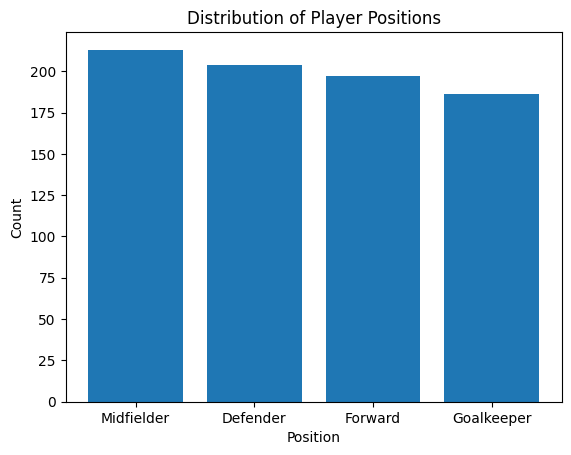

In [12]:
position_counts = df['Position'].value_counts()
plt.bar(position_counts.index, position_counts.values)
plt.xlabel('Position')
plt.ylabel('Count')
plt.title('Distribution of Player Positions')
plt.show()

In [13]:
df['Injury_Next_Season'].unique()

array([0, 1], dtype=object)

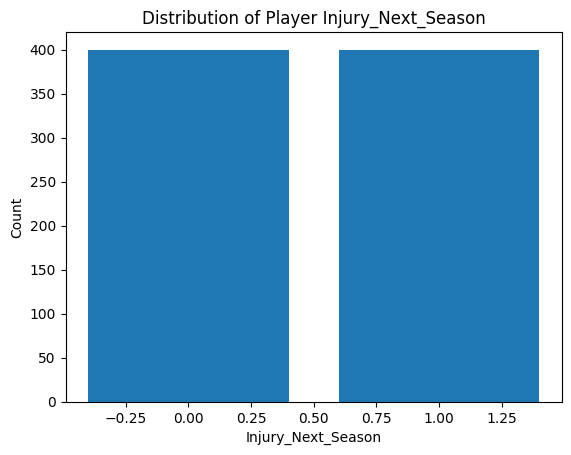

In [14]:
position_counts = df['Injury_Next_Season'].value_counts()
plt.bar(position_counts.index, position_counts.values)
plt.xlabel('Injury_Next_Season')
plt.ylabel('Count')
plt.title('Distribution of Player Injury_Next_Season')
plt.show()

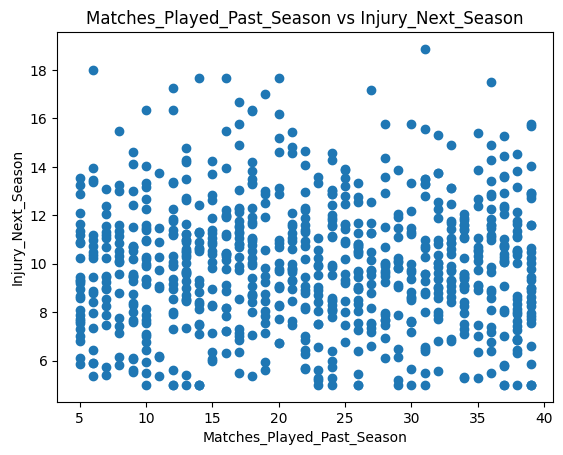

In [15]:
plt.scatter(df['Matches_Played_Past_Season'], df['Training_Hours_Per_Week'])
plt.xlabel('Matches_Played_Past_Season')
plt.ylabel('Injury_Next_Season')
plt.title('Matches_Played_Past_Season vs Injury_Next_Season')
plt.show()

In [16]:
# # Perform one-hot encoding on the 'Position' column
df = pd.get_dummies(df, columns=['Position'], drop_first=True)

# Display the first few rows to see the new columns
display(df.head())

,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,...,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI,Position_Forward,Position_Goalkeeper,Position_Midfielder
0,22,173,64,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,...,77.599705,8.238293,46.616415,81.472206,1,0,21.383942,False,False,True
1,18,170,67,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,...,94.418987,8.983737,49.368037,81.056677,1,0,23.183391,False,False,True
2,22,186,75,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,...,70.179176,7.229193,43.132808,64.877457,0,1,21.678807,True,False,False
3,20,172,62,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,...,83.473824,7.681029,51.528529,89.824744,1,0,20.957274,False,False,False
4,18,172,94,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,...,87.037256,6.728091,52.379718,71.569197,0,1,31.773932,False,False,True


In [17]:
# Select only numeric columns before calculating correlation
numeric_train =df.select_dtypes(include=np.number)
numeric_train.corr()

,Age,Height_cm,Weight_kg,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,BMI
Age,1.000000,0.001582,-0.014648,-0.047911,0.056699,-0.032542,-0.038488,-0.008860,0.001591,-0.022885,-0.046267,-0.008103,-0.029820,-0.011402,-0.012781,0.028784,-0.012502
Height_cm,0.001582,1.000000,0.020177,-0.047385,-0.014608,0.016819,-0.025384,-0.016925,-0.012708,-0.001085,0.002636,0.064941,0.010090,-0.004796,0.058373,-0.022400,-0.495986
Weight_kg,-0.014648,0.020177,1.000000,0.047871,-0.048474,-0.056834,-0.022744,0.006683,0.077848,0.022934,-0.018541,-0.018571,-0.020378,0.071611,-0.037670,-0.052486,0.854323
Training_Hours_Per_Week,-0.047911,-0.047385,0.047871,1.000000,0.001527,0.018461,0.040861,0.006640,0.031724,-0.031009,-0.070844,-0.015889,-0.041097,-0.044481,-0.009127,0.005913,0.063510
Matches_Played_Past_Season,0.056699,-0.014608,-0.048474,0.001527,1.000000,0.042946,0.057180,0.072365,-0.022907,0.021648,0.086571,0.014620,0.014914,0.003617,0.034873,0.027472,-0.033441
Previous_Injury_Count,-0.032542,0.016819,-0.056834,0.018461,0.042946,1.000000,-0.139387,-0.196505,0.202340,-0.250204,-0.129110,-0.152665,-0.124142,0.252749,-0.094875,-0.105226,-0.058099
Knee_Strength_Score,-0.038488,-0.025384,-0.022744,0.040861,0.057180,-0.139387,1.000000,0.181526,-0.161444,0.232618,0.229918,0.169224,0.271303,-0.264878,0.169021,0.140555,-0.006512
Hamstring_Flexibility,-0.008860,-0.016925,0.006683,0.006640,0.072365,-0.196505,0.181526,1.000000,-0.176159,0.206939,0.239867,0.211832,0.176318,-0.200827,0.183133,0.118480,0.009803
Reaction_Time_ms,0.001591,-0.012708,0.077848,0.031724,-0.022907,0.202340,-0.161444,-0.176159,1.000000,-0.218991,-0.192758,-0.237557,-0.208752,0.263146,-0.141793,-0.066638,0.074838
Balance_Test_Score,-0.022885,-0.001085,0.022934,-0.031009,0.021648,-0.250204,0.232618,0.206939,-0.218991,1.000000,0.205534,0.218329,0.252407,-0.252267,0.174079,0.146643,0.018927


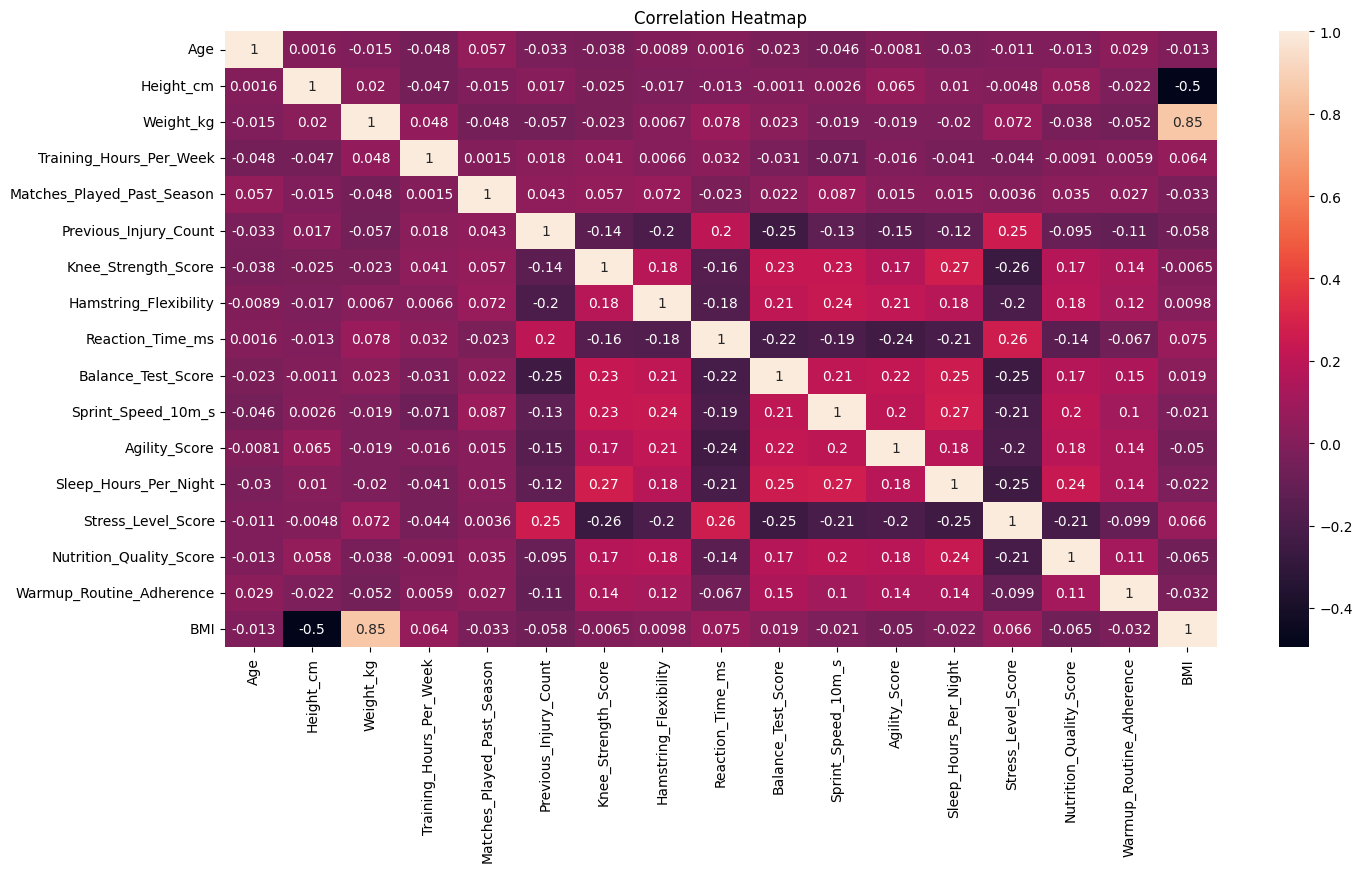

In [18]:
plt.figure(figsize=(16, 8))
sns.heatmap(numeric_train.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [19]:
# fit logistic regression
from sklearn import metrics
from sklearn.model_selection import train_test_split


In [20]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [21]:
from re import X
X_train = train.drop('Injury_Next_Season', axis=1)
y_train = train['Injury_Next_Season'].astype(int) # Convert to integer type

In [22]:
X_train.shape

(640, 20)

In [23]:
y_train.shape

(640,)

In [24]:
#test
X_test = test.drop('Injury_Next_Season', axis=1)
y_test = test['Injury_Next_Season'].astype(int) # Convert to integer type

In [25]:
X_test.shape


(160, 20)

In [26]:
y_test.shape

(160,)

In [27]:
# fit logistic regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [28]:
# train metrics f1, recall, precission,
y_pred = lr.predict(X_train)
print('Train Metrics')
print('f1 score: ', metrics.f1_score(y_train, y_pred))
print('recall: ', metrics.recall_score(y_train, y_pred))
print('precision: ', metrics.precision_score(y_train, y_pred))


Train Metrics
f1 score:  0.9577464788732394
recall:  0.95625
precision:  0.9592476489028213


In [29]:
#confusion matrix
cm = metrics.confusion_matrix(y_train, y_pred)
cm

array([[307,  13],
       [ 14, 306]])

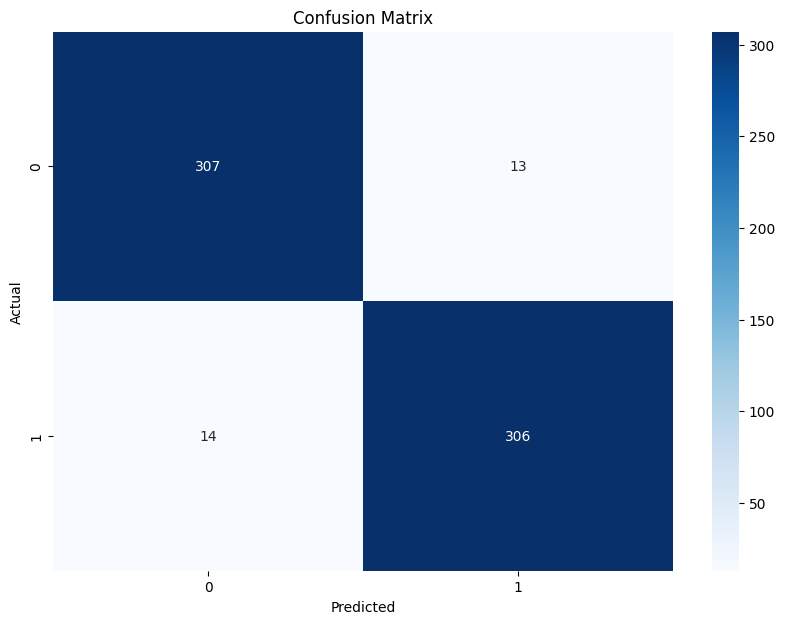

In [30]:
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# fit test set
y_pred = lr.predict(X_test)


In [32]:
#test metrics
print('Test Metrics')
print('f1 score: ', metrics.f1_score(y_test, y_pred))
print('recall: ', metrics.recall_score(y_test, y_pred))
print('precision: ', metrics.precision_score(y_test, y_pred))

Test Metrics
f1 score:  0.9212121212121213
recall:  0.95
precision:  0.8941176470588236


In [33]:
#CONFUSION MATRIX
cm = metrics.confusion_matrix(y_test, y_pred)
cm

array([[71,  9],
       [ 4, 76]])

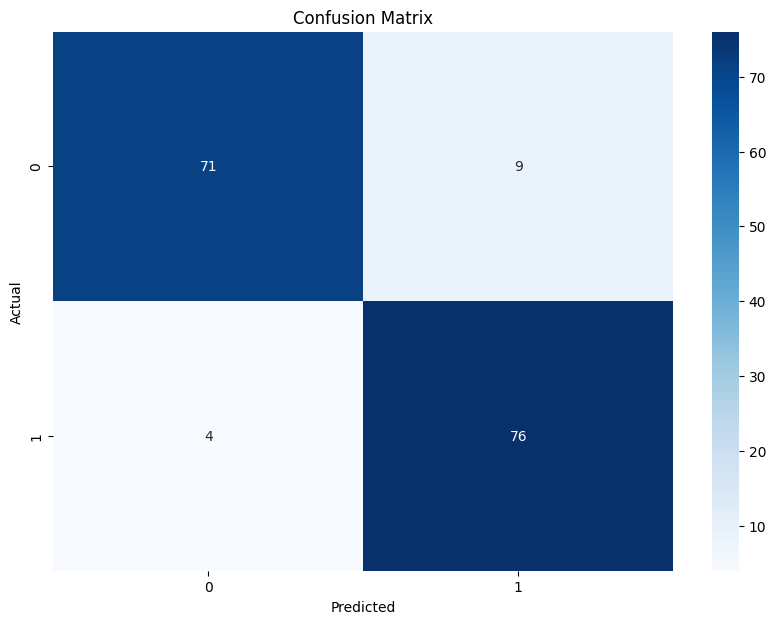

In [34]:
#PLOT CONFUSION MATRIX
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# SVM

In [35]:
#fit svm
svm = SVC()
svm.fit(X_train, y_train)

SVC()

In [36]:
#fit
y_pred = svm.predict(X_train)


In [37]:
#metrics train
print('Train Metrics')
print('f1 score: ', metrics.f1_score(y_train, y_pred))
print('recall: ', metrics.recall_score(y_train, y_pred))
print('precision: ', metrics.precision_score(y_train, y_pred))

Train Metrics
f1 score:  0.8958990536277602
recall:  0.8875
precision:  0.9044585987261147


In [38]:
#confusion matrix
cm = metrics.confusion_matrix(y_train, y_pred)
cm

array([[290,  30],
       [ 36, 284]])

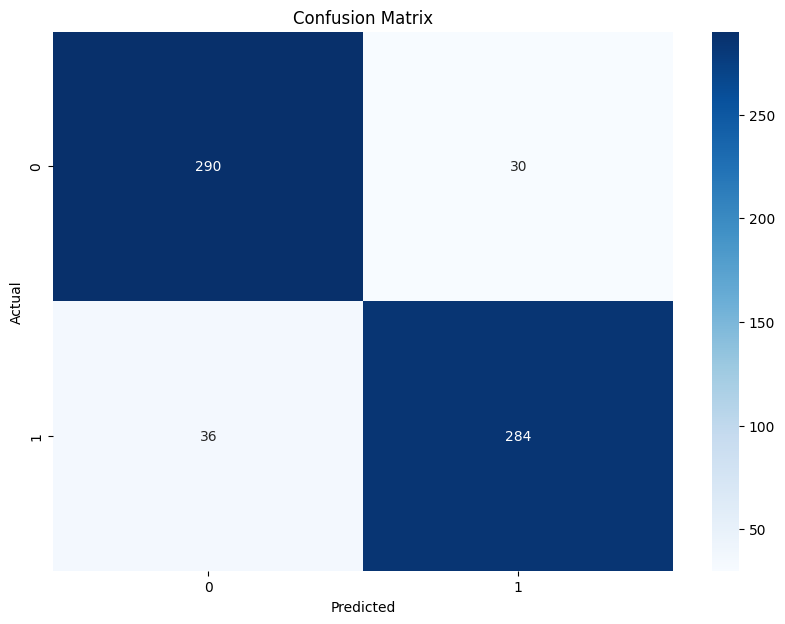

In [39]:
# plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [40]:
#TEST
y_pred_test = svm.predict(X_test)


In [41]:
#Metrics test
print('Test Metrics')
print('f1 score: ', metrics.f1_score(y_test, y_pred_test))
print('recall: ', metrics.recall_score(y_test, y_pred_test))
print('precision: ', metrics.precision_score(y_test, y_pred_test))

Test Metrics
f1 score:  0.9202453987730062
recall:  0.9375
precision:  0.9036144578313253


In [42]:
#confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred_test)
cm

array([[72,  8],
       [ 5, 75]])

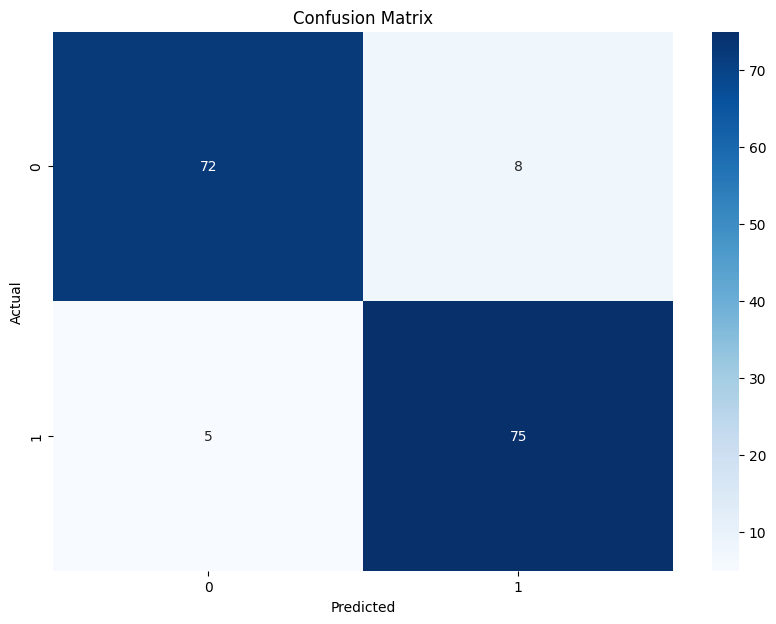

In [43]:
# plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
